In [3]:
import sys
import pandas as pd
import json
import ollama

In [4]:
df_neg = pd.read_csv('data/codex/test_negatives.txt', sep='\t', header=None, names=['Head','Relation','Tail'])

In [5]:
df_pos = pd.read_csv('data/codex/test.txt', sep='\t', header=None, names=['Head','Relation','Tail'])

In [6]:
with open('data/codex/entities.json', 'r') as file:
    entities = json.load(file)

with open('data/codex/relations.json', 'r') as file:
    relations = json.load(file)

In [7]:
name_dict = {}
for id, row in df_pos.iterrows():
    # get id
    head_id = row['Head']
    relation_id = row['Relation']
    tail_id = row['Tail']
    # get label out of id
    head = entities[head_id]['label']
    relation = relations[relation_id]['label']
    tail = entities[tail_id]['label']
    name_dict[id] = [head,relation,tail]


In [8]:
name_df_pos = pd.DataFrame.from_dict(name_dict,orient='index',columns=['Head','Relation','Tail'])
name_df_pos['Valid'] = 1

In [9]:
name_dict = {}
for id, row in df_neg.iterrows():
    # get id
    head_id = row['Head']
    relation_id = row['Relation']
    tail_id = row['Tail']
    # get label out of id
    head = entities[head_id]['label']
    relation = relations[relation_id]['label']
    tail = entities[tail_id]['label']
    name_dict[id] = [head,relation,tail]


In [10]:
name_df_neg = pd.DataFrame.from_dict(name_dict,orient='index',columns=['Head','Relation','Tail'])
name_df_neg['Valid'] = 0

In [11]:
name_df = pd.concat([name_df_neg, name_df_pos]).reset_index(drop=True)

In [12]:
# Function to interract with llm

def row2text(row):
    # Translate triple into text
    head = row['Head']
    relation = row['Relation']
    tail = row['Tail']
    prompt = f"Transform the following triple :({head},{relation},{tail}) into natural language text. Don't explain your choice"
    response = ollama.generate(model='mistral', 
            prompt= prompt)
    triple_text = response['response']
    return triple_text, head, relation, tail

def extract_score(text):
    # Function to extract score
    # Find the starting index of "Score: "
    start_index = text.find("Score: ") + len("Score: ")

    # Find the end of the number, which could be marked by a non-digit character
    end_index = start_index
    while end_index < len(text) and (text[end_index].isdigit() or text[end_index] == '.'):
        end_index += 1

    # Extract and return the number using slicing
    return text[start_index:end_index]

In [13]:
# eval without context
def eval_text(triple_text):
    # give a score for a text
    prompt = f'We have the below sentence and you need to validate that and give a score to that.'
    prompt += f'given that a 0 is a score corresponding to invalide triple and 1 to valide triple give the corresponding score to this triple.'
    prompt += f"Is the following sentence :'{triple_text}' valid."
    prompt += f"Start your answer with :'Score:', if you can not determine if it is accurate give it a score of 0.5"
    response = ollama.generate(model='mistral', 
            prompt= prompt)
    text = response['response']
    #print('Eval text:\n')
    #print(text)
    score = extract_score(text)
    return score

def eval_df(df, size):
    # evaluate subsample of df with llm
    score_list = []
    idx = 0
    for index, row in df[:size].iterrows():
        triple_text, head, relation, tail = row2text(row)
        #print('Triple text:\n')
        #print(triple_text)
        score = eval_text(triple_text)
        score_list.append(score)
        idx+= 1
        if idx%100 == 0:
            print(f'{idx}/{size}')
    print('Finished\n')
    return score_list


In [33]:
# Function to get context

def get_context_triple(df:pd.DataFrame, col_name:str, elem_comp:str, max_sample:int) -> list[str]:
    # get context triple
    context_df = df[df[col_name] == elem_comp]
    if len(context_df) > max_sample:
        context_df = context_df.sample(max_sample)
    list_triple = []
    for _,context_row in context_df.iterrows():
        head = context_row['Head']
        relation = context_row['Relation']
        tail = context_row['Tail']
        list_triple.append(f'({head},{relation},{tail})')
    return list_triple

def eval_text_context(triple_text, context_head, context_rel, context_tail):
    # give a score for a text with context
    prompt = f'We have the below sentence and you need to validate that and give a score to that.'
    prompt += f'given that a 0 is a score corresponding to invalid sentence and 1 to valid sentence give the corresponding score to this triple.'
    prompt += f"Is the following sentence :'{triple_text}' valid."
    prompt += f"The following triples are example of triples that have the same head:{context_head}."
    prompt += f"The following triples are example of triples that have the same relation:{context_rel}."
    prompt += f"The following triples are example of triples that have the same tail:{context_tail}."
    prompt += f"Start your answer with :'Score:', if you can not determine if it is accurate give it a score of 0.5"
    response = ollama.generate(model='mistral', 
            prompt= prompt)
    text = response['response']
    #print('Eval text:\n')
    #print(text)
    score = extract_score(text)
    return score

def eval_df_context(df, size):
    # evaluate subsample of df with llm and context
    score_list = []
    idx = 0
    for index, row in df[:size].iterrows():
        
        triple_text, head, relation, tail = row2text(row)
        #print('Triple text:\n')
        #print(triple_text)
        # get context for relations
        context_rel = get_context_triple(df, 'Relation', relation, 5)
        #print(f'Relation: {relation} \tRelation context:')
        #print(context_rel)

        # get context for head
        context_head = get_context_triple(df, 'Head', head, 3)
        #print(f'Head: {head}\tHead context')
        #print(context_head)

        # get context for tail
        context_tail = get_context_triple(df, 'Tail', tail, 3)
        #print(f'Tail: {tail}\tTail context')
        #print(context_tail)
        
        score = eval_text_context(triple_text, context_head, context_rel, context_tail)
        score_list.append(score)
        idx+= 1
        if idx%100 == 0:
            print(f'{idx}/{size}')
    print('Finished\n')
    return score_list


In [15]:
size = 100
base_list = eval_df(name_df, size)
#base_cand_list = eval_df(candidates_df, size)

cont_list = eval_df_context(name_df, size)
#cont_cand_list = eval_df_context(candidates_df, size)

100/100
Finished

Relation: country of citizenship 	Relation context:
['(Fredric Jameson,country of citizenship,India)', '(Guglielmo Marconi,country of citizenship,German Empire)', '(Natalie Portman,country of citizenship,United Kingdom)', '(Bud Spencer,country of citizenship,Brazil)', '(Charles Dickens,country of citizenship,Spain)']
Head: Mickey Rooney	Head context
['(Mickey Rooney,country of citizenship,Sweden)', '(Mickey Rooney,country of citizenship,Israel)', '(Mickey Rooney,time period,20th century)']
Tail: Denmark	Tail context
['(Andy Griffith,country of citizenship,Denmark)', '(Robert De Niro,country of citizenship,Denmark)', '(Bruce Willis,country of citizenship,Denmark)']
Relation: country of citizenship 	Relation context:
['(Rainer Werner Fassbinder,country of citizenship,Germany)', '(Chord Overstreet,country of citizenship,Canada)', '(Ernst Troeltsch,country of citizenship,Hungary)', '(Lenny Kravitz,country of citizenship,Canada)', '(Ilya Ilf,country of citizenship,Germany)

In [35]:
size = 100
pos_list = eval_df(df_pos, size)
#base_cand_list = eval_df(candidates_df, size)

cont_pos_list = eval_df_context(df_pos, size)
#cont_cand_list = eval_df_context(candidates_df, size)

100/100
Finished

100/100
Finished



In [16]:
def clean_score(list_score, thresh) -> list[float]:
    list_score = [item.rstrip('.') if item.endswith('.') else item for item in list_score]
    list_score = [item for item in list_score if item and item.strip()]
    score_bin = [1 if float(item) > thresh else 0 for item in list_score]
    return score_bin

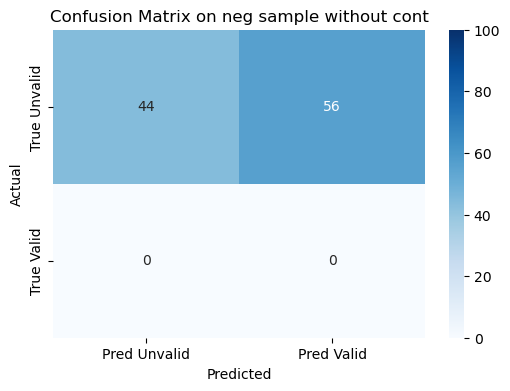

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

thresh = 0.6
prediction_base = clean_score(base_list, thresh)
truth_base = name_df[:size]['Valid'].tolist()

# Generate the confusion matrix
cm = confusion_matrix(truth_base, prediction_base)

# Display the confusion matrix using seaborn heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Pred Unvalid', 'Pred Valid'], yticklabels=['True Unvalid', 'True Valid'],  vmin=0, vmax=100)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix on neg sample without cont')
plt.show()


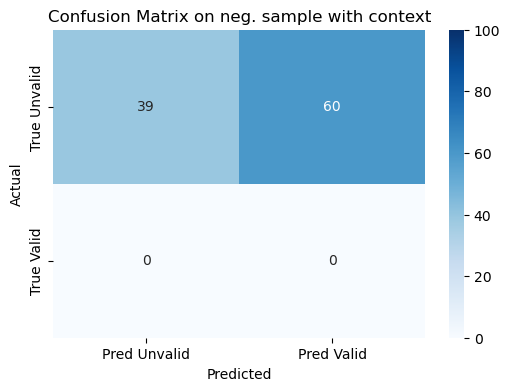

In [69]:
thresh = 0.6
# RESULT ON FB WITHOUT CONTEXT
prediction_cont = clean_score(cont_list, thresh)
truth_base = name_df[:size-1]['Valid'].tolist()

# Generate the confusion matrix
cm = confusion_matrix(truth_base, prediction_cont)

# Display the confusion matrix using seaborn heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Pred Unvalid', 'Pred Valid'], yticklabels=['True Unvalid', 'True Valid'], vmin=0, vmax=100)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix on neg. sample with context')
plt.show()

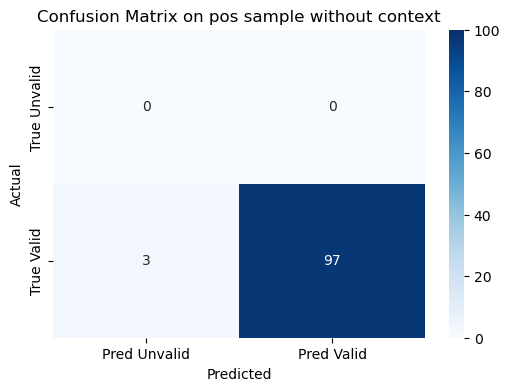

In [77]:
thresh = 0.6
prediction_base = clean_score(pos_list, thresh)
truth_base = name_df_pos[:size]['Valid'].tolist()

# Generate the confusion matrix
cm = confusion_matrix(truth_base, prediction_base)

# Display the confusion matrix using seaborn heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Pred Unvalid', 'Pred Valid'], yticklabels=['True Unvalid', 'True Valid'],  vmin=0, vmax=100)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix on pos sample without context')
plt.show()


In [80]:

print(cm)

[[  0   0]
 [  0 100]]


/opt/homebrew/Caskroom/miniconda/base/envs/kg-emb/lib/python3.12/site-packages/sklearn/metrics/_classification.py:386: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


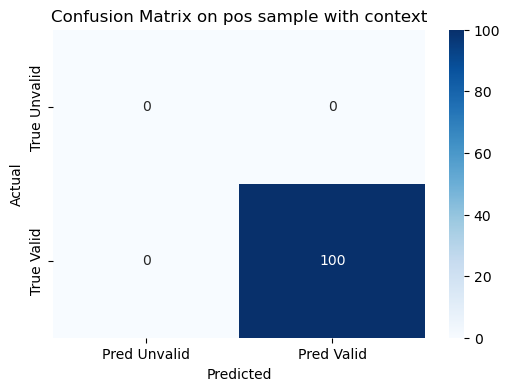

In [82]:
thresh = 0.6
# RESULT ON FB WITHOUT CONTEXT
prediction_cont = clean_score(cont_pos_list, thresh)
truth_base = name_df_pos[:size]['Valid'].tolist()

# Generate the confusion matrix
cm = confusion_matrix(truth_base, prediction_cont)
cm = np.array([[0,0],[0,100]])

# Display the confusion matrix using seaborn heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Pred Unvalid', 'Pred Valid'], yticklabels=['True Unvalid', 'True Valid'], vmin=0, vmax=100)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix on pos sample with context')
plt.show()

In [21]:
import pandas as pd
from cand_gen.embedding import train_model
from cand_gen import triple_gen

/opt/homebrew/Caskroom/miniconda/base/envs/kg-emb/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [22]:
train_df = train_model.create_dataset(
    name_df)
test_df = train_model.create_dataset(
    name_df.sample(n=50))

model_name = "TransE"
embedding_dim = 5


model_kwargs = {"embedding_dim": embedding_dim}
experiment_name = model_name+f"_dim{embedding_dim}"
model = train_model.create_pipeline(train_df, test_df,
                    model_name, model_kwargs, experiment_name)

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: fieng. Use `wandb login --relogin` to force relogin


No cuda devices were available. The model runs on CPU
Training epochs on cpu: 100%|██████████| 50/50 [00:05<00:00,  8.47epoch/s, loss=0.165, prev_loss=0.159]
Evaluating on cpu:   0%|          | 0.00/50.0 [00:00<?, ?triple/s]WARNING:torch_max_mem.api:Encountered tensors on device_types={'cpu'} while only ['cuda'] are considered safe for automatic memory utilization maximization. This may lead to undocumented crashes (but can be safe, too).
Evaluating on cpu: 100%|██████████| 50.0/50.0 [00:00<00:00, 977triple/s]
INFO:pykeen.evaluation.evaluator:Evaluation took 0.06s seconds


loss,█▆▅▄▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
testing.both.optimistic.adjusted_arithmetic_mean_rank,▁
testing.both.optimistic.adjusted_arithmetic_mean_rank_index,▁
testing.both.optimistic.adjusted_geometric_mean_rank_index,▁
testing.both.optimistic.adjusted_hits_at_k,▁
testing.both.optimistic.adjusted_inverse_harmonic_mean_rank,▁
testing.both.optimistic.arithmetic_mean_rank,▁
testing.both.optimistic.count,▁
testing.both.optimistic.geometric_mean_rank,▁
testing.both.optimistic.harmonic_mean_rank,▁
testing.both.optimistic.hits_at_1,▁


In [26]:
import numpy as np
import pykeen
from pykeen.pipeline import pipeline
from pykeen.models import TransE
from pykeen.triples import TriplesFactory

def get_triplet_emb(model: pykeen.models.TransE, triple_factory: pykeen.triples.TriplesFactory,
                    head: str, relation: str, tail: str) -> (np.ndarray, np.ndarray, np.ndarray):
    """ Return the triplet embedding from model, dataset and triplet list """
    # get total entity embedding
    entities_embedding = model.entity_representations[0](
        indices=None).detach().numpy()
    # get total relation embedding
    relations_embedding = model.relation_representations[0](
        indices=None).detach().numpy()

    # get id of each element of the triplet
    head_id = triple_factory.entity_to_id[head]
    relation_id = triple_factory.relation_to_id[relation]
    tail_id = triple_factory.entity_to_id[tail]

    # get every element embedding
    head_emb = entities_embedding[head_id]
    relation_emb = relations_embedding[relation_id]
    tail_emb = entities_embedding[tail_id]
    return (head_emb, relation_emb, tail_emb)


def compute_dist_emb(head_emb: np.ndarray, relation_emb: np.ndarray, tail_emb: np.ndarray) -> np.float32:
    """ Return computed distance of embedding """
    # sum of head and relation
    sum_head_relation = head_emb + relation_emb
    # difference between sum of head and relation and tail
    distance = np.linalg.norm(sum_head_relation - tail_emb)
    return distance


def get_list_dist(df: pd.DataFrame, model: pykeen.models.TransE, triple_factory: pykeen.triples.TriplesFactory,) -> list[np.float32]:
    """ Return list of distance for every embedded triple """
    # list of distance
    list_dist = []
    # iterate over the DataFrame
    for index, row in df.iterrows():
        head = row['Head']
        relation = row['Relation']
        tail = row['Tail']
        # get embedding
        head_emb, rel_emb, tail_emb = get_triplet_emb(
            model, triple_factory, head, relation, tail)
        # get distance of every triplet
        dist = compute_dist_emb(head_emb, rel_emb, tail_emb)
        list_dist.append(dist)
    return list_dist

In [28]:
from cand_gen import triple_gen

candidates_df = triple_gen.generate_all_candidates(name_df)
list_dist = get_list_dist(candidates_df, model.model, train_df)
candidates_df['distance'] = list_dist

In [31]:
to_annotate_df  = candidates_df.sample(100)

In [38]:
list_dist_pos = get_list_dist(name_df_pos, model.model, train_df)
name_df_pos['distance'] = list_dist_pos
list_dist_neg = get_list_dist(name_df_neg, model.model, train_df)
name_df_neg['distance'] = list_dist_neg

In [42]:
name_df_pos['distance'].mean()

1.0094334

In [43]:
name_df_neg['distance'].mean()

1.1164976

In [44]:
candidates_df['distance'].mean()

1.4811419

In [45]:
name_df_pos

,Head,Relation,Tail,Valid,distance
0,Gaspard Monge,country of citizenship,France,1,1.173752
1,Leon Russell,occupation,mandolinist,1,1.531062
2,Mos Def,occupation,singer,1,1.269504
3,Max Frisch,genre,prose,1,1.156976
4,Bulat Okudzhava,location of formation,Soviet Union,1,3.267163
...,...,...,...,...,...
1823,Gackt,genre,rock music,1,1.586515
1824,Chuck Berry,country of citizenship,United States of America,1,0.884906
1825,Zambia,diplomatic relation,Ethiopia,1,0.493619
1826,Jaan Kaplinski,country of citizenship,Estonia,1,1.080974


In [55]:
df_dict = {
    1:['remedesivir','inhibit','sars-cov-2'],
    2:['chloroquine','inhibit','sars-cov-2'],
    3:['remedesivir','treats','2019-ncov'],
    4:['miclosamide','prevents','sars-cov2'],
    5:['chloroquine','approves','FDA'],
    6:['remedesivir','affects','MERS'],
    7:['remedesivir','affects','severe-covid-19'],
}

In [57]:
df_test = pd.DataFrame.from_dict(df_dict, orient='index',columns=['Head','Relation','Tail'])

In [59]:
test_candidates = triple_gen.generate_all_candidates(df_test)

In [60]:
test_candidates

,Head,Relation,Tail
0,remedesivir,approves,FDA
1,chloroquine,treats,2019-ncov
2,chloroquine,affects,MERS
3,chloroquine,affects,severe-covid-19


In [ ]:
train_df = train_model.create_dataset(
    df_test)
test_df = train_model.create_dataset(
    df_test.sample(n=7))

model_name = "TransE"
embedding_dim = 5


model_kwargs = {"embedding_dim": embedding_dim}
experiment_name = model_name+f"_dim{embedding_dim}"
model = train_model.create_pipeline(train_df, test_df,
                    model_name, model_kwargs, experiment_name)

In [67]:
list_dist = get_list_dist(test_candidates, model.model, train_df)
test_candidates['distance'] = list_dist

In [68]:
test_candidates

,Head,Relation,Tail,distance
0,remedesivir,approves,FDA,1.903520
1,chloroquine,treats,2019-ncov,1.818840
2,chloroquine,affects,MERS,1.421086
3,chloroquine,affects,severe-covid-19,1.767888


In [61]:
size = 100
test_list = eval_df(test_candidates, size)
#base_cand_list = eval_df(candidates_df, size)

cont_test_list = eval_df_context(test_candidates, size)

Finished

Finished



In [62]:
test_list

['1.', '1.', '1.', '1.']

In [64]:
cont_test_list

['1.', '1.', '1.', '1.']